### Mohammed Omar Mkhallati
### AI for Cybersecurity
### Monday, September 21, 2026
### Practical Exercise: IQR Outlier Detection
### Source: https://www.kaggle.com/datasets/hassan06/nslkdd

#### Import Statements

In [1]:
from urllib.request import urlopen
import ssl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Loading the NSL-KDD Dataset

In [2]:
ssl._create_default_https_context = ssl._create_unverified_context

url = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.csv'

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

html = urlopen(url)
df = pd.read_csv(html, names=columns, lineterminator='\r')

# Collapse the label into binary normal / attack for the outlier check later
df['is_attack'] = (df['label'] != 'normal').astype(int)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,is_attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


#### The IQR Function

In [3]:
def iqr_outliers(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

#### Applying IQR to Key Traffic Features

In [4]:
features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

results = []
for feat in features:
    mask, lower, upper = iqr_outliers(df[feat])
    results.append({
        'feature': feat,
        'lower_bound': lower,
        'upper_bound': upper,
        'num_outliers': mask.sum(),
        'pct_outliers': round(mask.mean() * 100, 2)
    })
    df[f'{feat}_outlier'] = mask

summary = pd.DataFrame(results)
summary

,feature,lower_bound,upper_bound,num_outliers,pct_outliers
0,duration,0.0,0.0,10018,7.95
1,src_bytes,-414.0,690.0,13840,10.99
2,dst_bytes,-774.0,1290.0,23579,18.72
3,count,-209.5,354.5,3157,2.51
4,srv_count,-22.0,42.0,12054,9.57


#### Visualizing the Spread

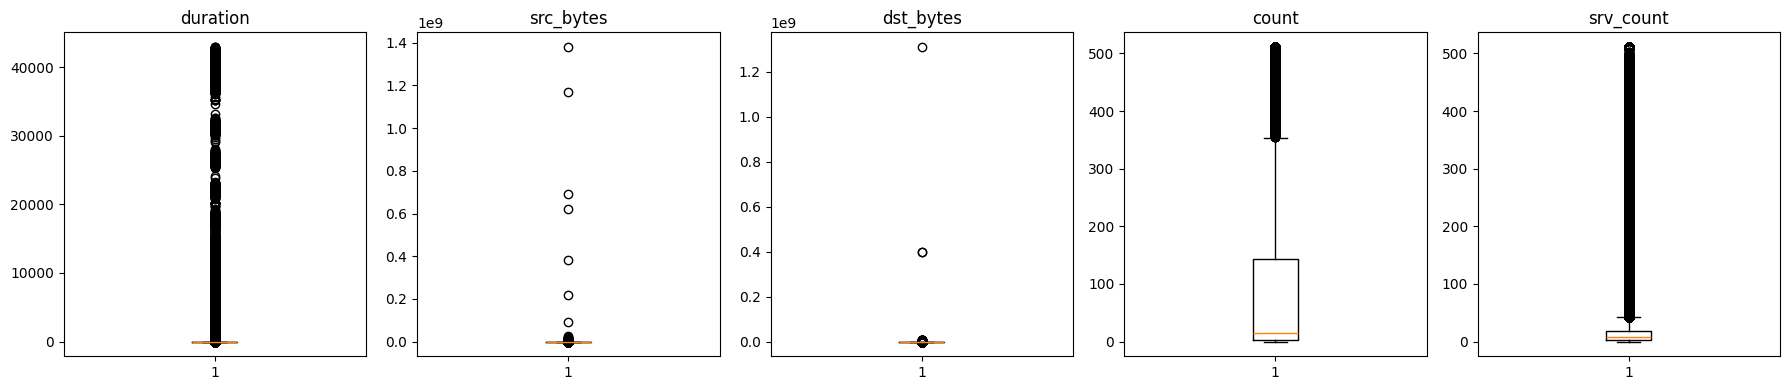

In [5]:
fig, axes = plt.subplots(1, len(features), figsize=(18, 4))
for ax, feat in zip(axes, features):
    ax.boxplot(df[feat], vert=True)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

#### Do the Outliers Make Sense?

In [6]:
for feat in features:
    col = f'{feat}_outlier'
    rate = df.groupby(col)['is_attack'].mean() * 100
    print(f"{feat}: attack rate among non-outliers = {rate.loc[False]:.1f}%, "
          f"among outliers = {rate.loc[True]:.1f}%")

duration: attack rate among non-outliers = 48.8%, among outliers = 20.6%
src_bytes: attack rate among non-outliers = 49.1%, among outliers = 26.1%
dst_bytes: attack rate among non-outliers = 56.0%, among outliers = 5.6%
count: attack rate among non-outliers = 45.3%, among outliers = 95.3%
srv_count: attack rate among non-outliers = 48.1%, among outliers = 32.2%


Only count lines up with attacks the way you'd expect: outliers there are 95.3% attacks versus 45.3% for normal-range values, which fits scanning and flooding behavior (many connections to the same host in a short window).

The byte-based features go the other way. dst_bytes outliers are only 5.6% attacks, and src_bytes and srv_count outliers are also less attack-heavy than the non-outlier group. This makes sense once you look at how these attacks work: floods like neptune and smurf often carry small or zero byte counts, while the extreme byte-count outliers tend to be large legitimate transfers. So a high volume of bytes is not what marks these attacks, a high volume of connections is.

This is a good illustration of why IQR outliers need to be read per feature rather than treated as a generic attack signal. On count, an outlier is a strong lead. On dst_bytes, an outlier is more likely to be an unusually large but normal connection, and the real attack signal in this dataset sits somewhere else (e.g. in the small-byte, high-frequency traffic that IQR does not flag as extreme).